In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [16]:
lattice_str = "sawtooth"
lattice_len = 11
lattice_dim = (lattice_len, 1)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

H_total = H_bare

In [25]:
def plot_ST_CLS(ax, tb_model: E9tb.tbmodel_2D, pos):
    i, j, k = pos
    if k != 0: raise(ValueError("wrong CLS position (it's the bottom site)"))
    all_corners = [(i - 1, j, 1), (i, j, 0), (i, j, 1)]
    all_pos = [tb_model.get_lat_pos(p) for p in all_corners]
    filled_pos = [all_corners[1]]

    CLS_dict = {"color": "blue", "linewidth": 3}
    site1_dict = {"color": "blue", "s": 50, "edgecolors": "blue", "linewidth": 2}
    site2_dict = {"color": "white", "s": 50 / np.sqrt(2), "edgecolors": "blue", "linewidth": 2}
    for pos1, pos2 in zip(all_pos[:-1], all_pos[1:]):
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], **CLS_dict)
    ax.scatter(*all_pos[0], **site2_dict, zorder = 100)
    ax.scatter(*all_pos[1], **site1_dict, zorder = 100)
    ax.scatter(*all_pos[2], **site2_dict, zorder = 100)

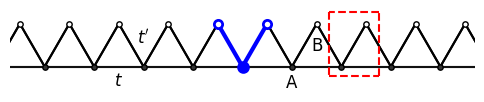

In [39]:
fig, ax = plt.subplots(1, 1, figsize = (6, 2))

ax.axis("off")
my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["#333333", "#FFFFFF"],
                sublat_kwargs = {"edgecolors": "black",
                                    "linewidths": 1})

ax.text(2.5, -0.1, r"$t$", ha = "center", va = "top", fontsize = 12)
ax.text(3, 0.4, r"$t'$", ha = "center", va = "bottom", fontsize = 12)
ax.text(6, -0.15, "A", ha = "center", va = "top", fontsize = 12)
ax.text(6.5, 0.6, "B", ha = "center", va = "top", fontsize = 12)

box_corners = [(6.75, -0.2), (7.75, -0.2), (7.75, 1.1), (6.75, 1.1), (6.75, -0.2)]
for p1, p2 in zip(box_corners[:-1], box_corners[1:]):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle = "--", color = "red")

ax.set_xlim(0.3, 9.7)
ax.set_ylim(-0.25, 1.15)
ax.set_xticks([])
ax.set_yticks([])

plot_ST_CLS(ax, my_tb_model, (5, 0, 0))

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "ST_tb.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')